<a href="https://colab.research.google.com/github/SIMETHY/Telecom_customer_chrun/blob/main/Telecom_chrun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Prediction (Classification)**

# **Problem Statement**

Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:
- Customer Age
- Gender
- Tenure
- Monthly Charges
- Total Charges
- Contract Type
- Payment Method
- Internet Service
- Tech Support
- Online Security
- Customer Support Calls

We are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

# **Objectives**

The objective of this task is to:
- Understand and explore the customer dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model

# **Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**

In [2]:
df = pd.read_csv('telecom_churn_data.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# **Basic checks**

In [4]:
# No of Rows and Columns
df.shape

(7043, 21)

In [5]:
# Name of columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# Datatypes used
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
# Summary of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **Handling Missing Values**

**Gender**

In [9]:
df['gender'].dtypes

dtype('O')

In [10]:
df['gender'].mode()[0]

'Male'

In [11]:
df['gender'] = df['gender'].fillna(df['gender'].mode().iloc[0])

**TotalCharges**

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df['TotalCharges'].dtypes

dtype('float64')

In [14]:
df['TotalCharges'].median()

1397.3

In [15]:
df['TotalCharges'].skew()

np.float64(0.9616058347613503)

In [16]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

**MonthlyCharges**

In [17]:
df['MonthlyCharges']=pd.to_numeric(df['MonthlyCharges'], errors='coerce')

In [18]:
df['MonthlyCharges'].dtypes

dtype('float64')

In [19]:
df['MonthlyCharges'].median()

70.35

In [20]:
df['MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

In [21]:
df['MonthlyCharges']=df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

**PaperlessBilling**

In [22]:
df['PaperlessBilling'].dtypes

dtype('O')

In [23]:
df['PaperlessBilling'].mode()[0]

'Yes'

In [24]:
df['PaperlessBilling']=df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0])

In [25]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Null values are handled

# **Check for duplicates**

In [26]:
df.duplicated().sum()

np.int64(0)

NO duplicated values

Lets Group columns

In [27]:
df.drop('customerID', axis=1, errors='ignore', inplace=True)

In [28]:
num_cols = df.select_dtypes(include=['int64','float64'])
num_cols

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [29]:
cat_cols = df.select_dtypes(include='object')
cat_cols

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


# **Exploratory Data Analysis**

# **Univariate Analysis**

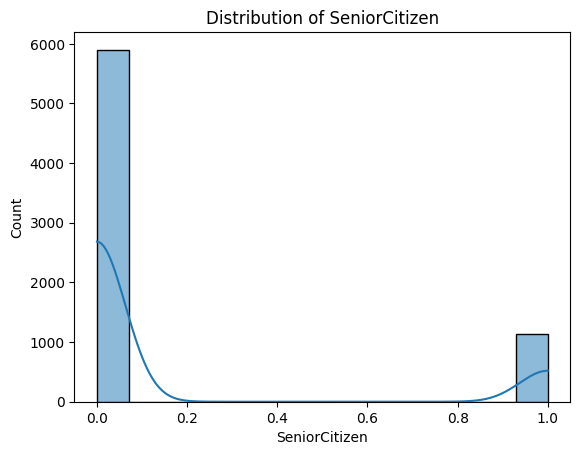

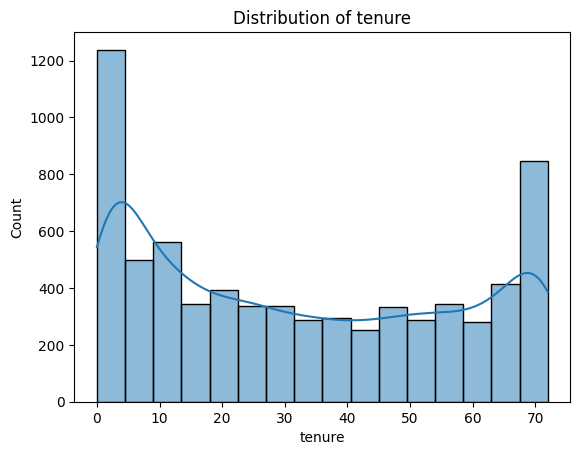

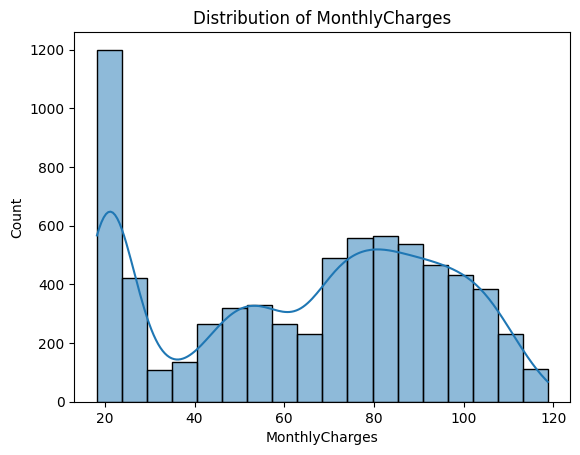

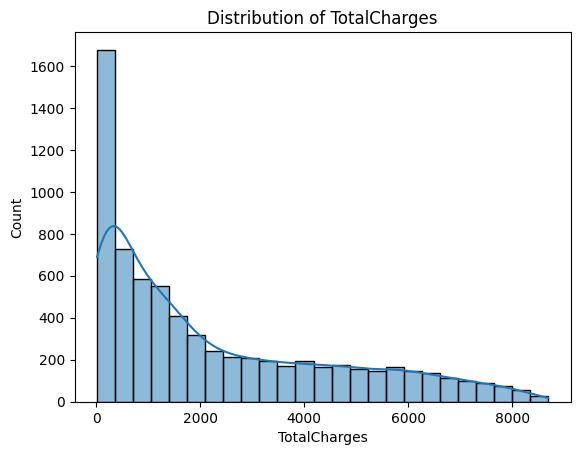

In [30]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

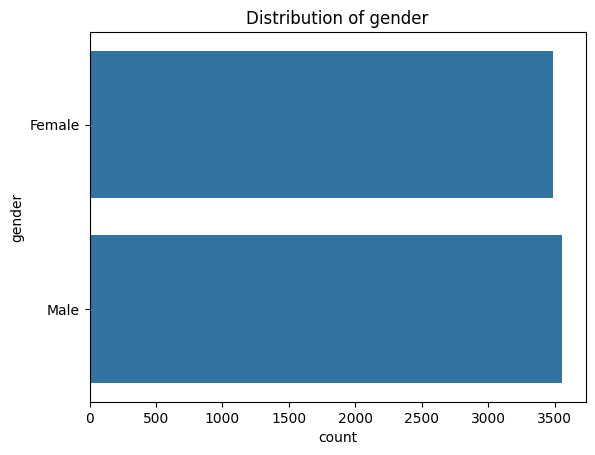

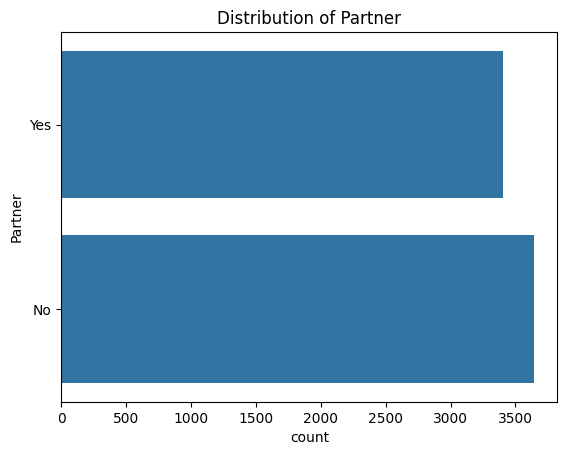

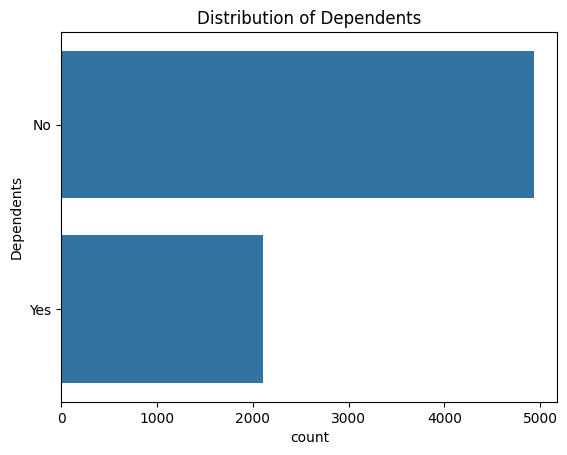

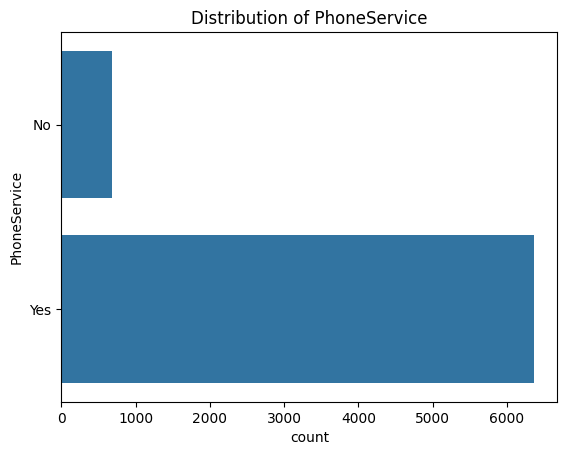

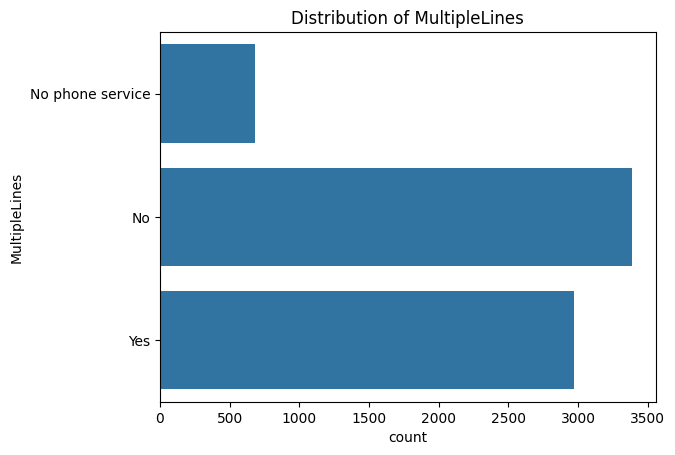

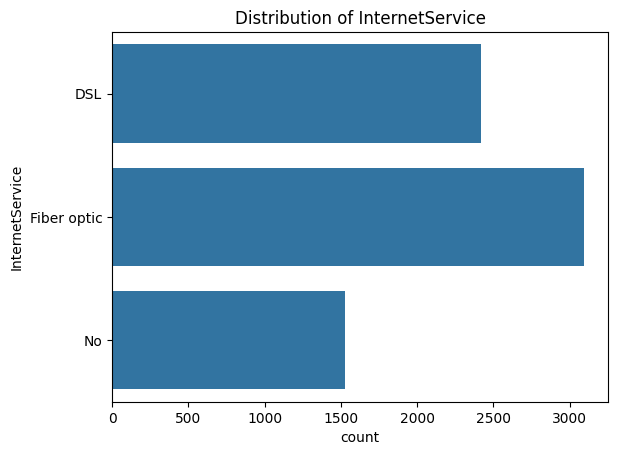

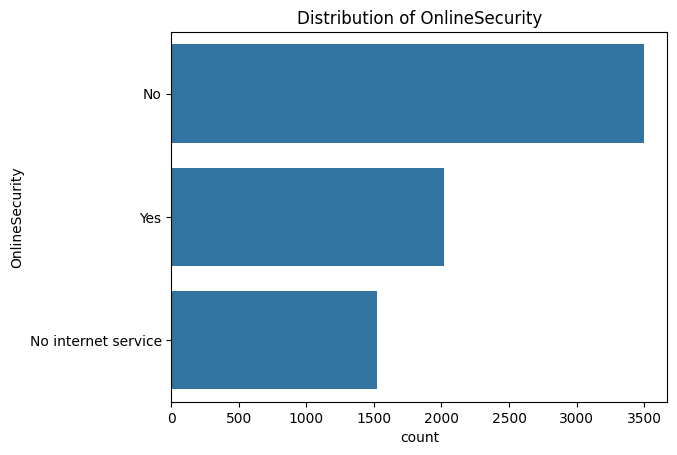

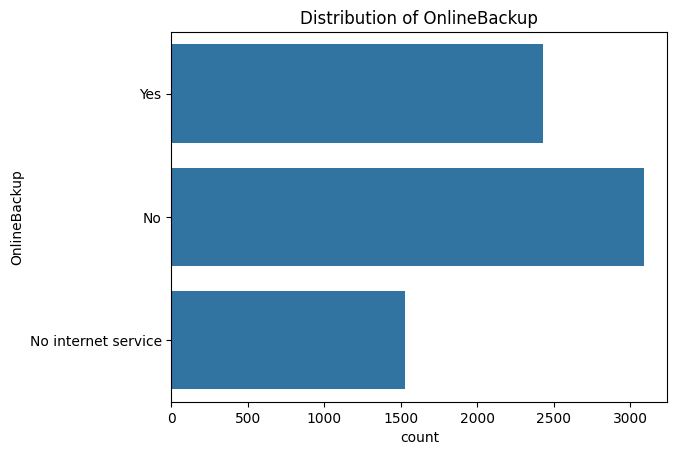

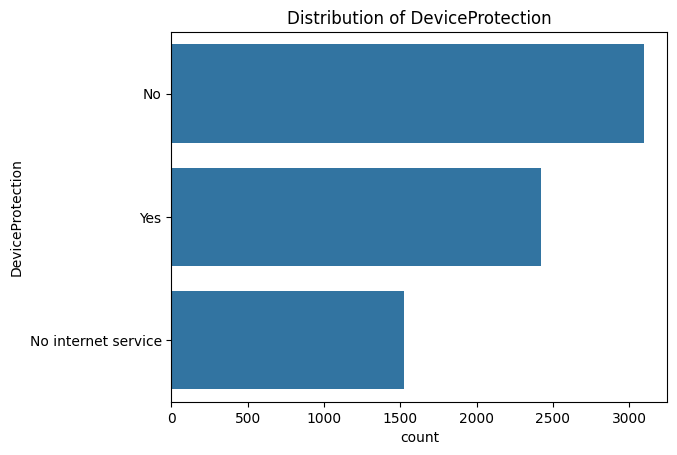

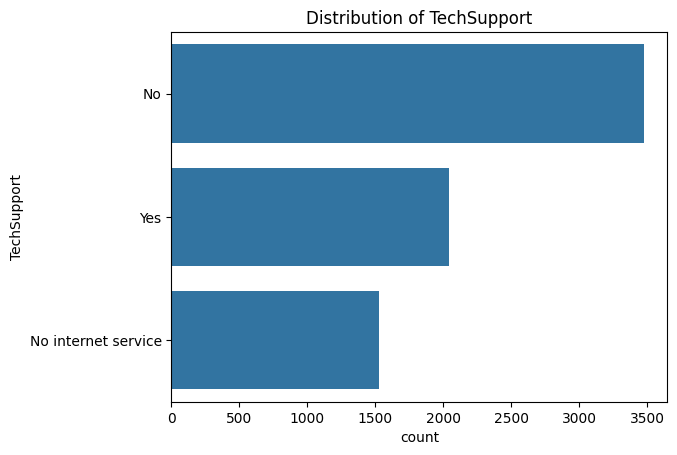

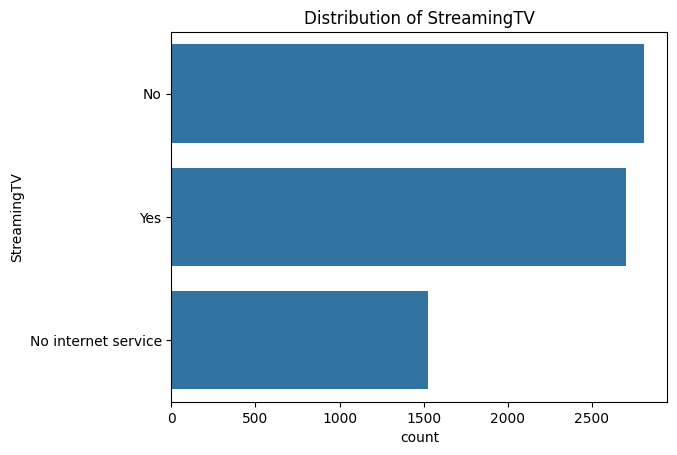

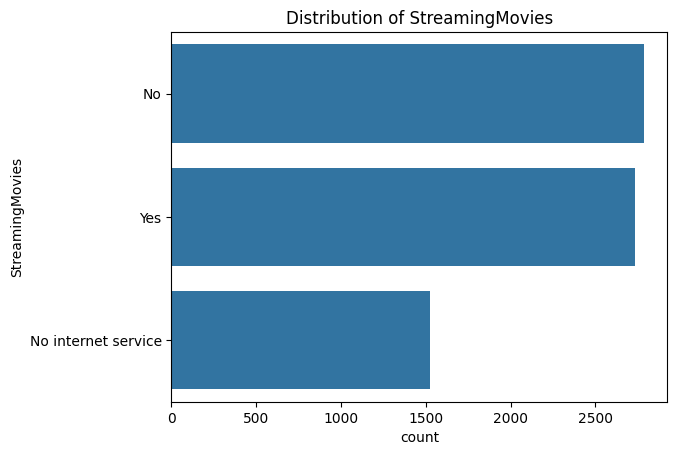

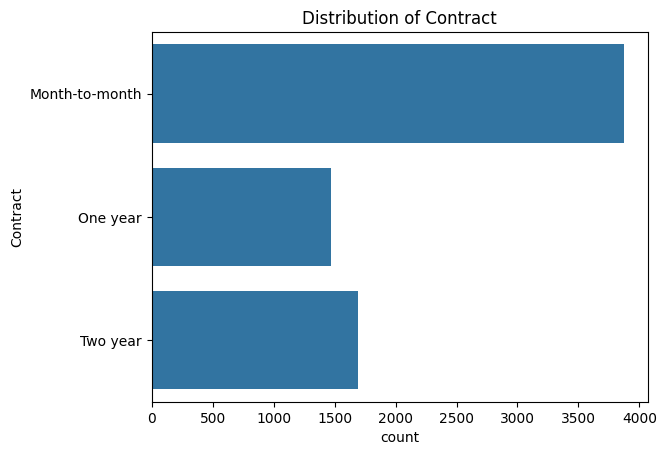

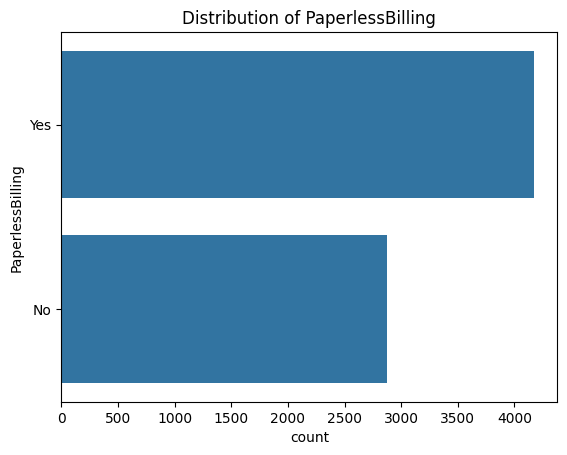

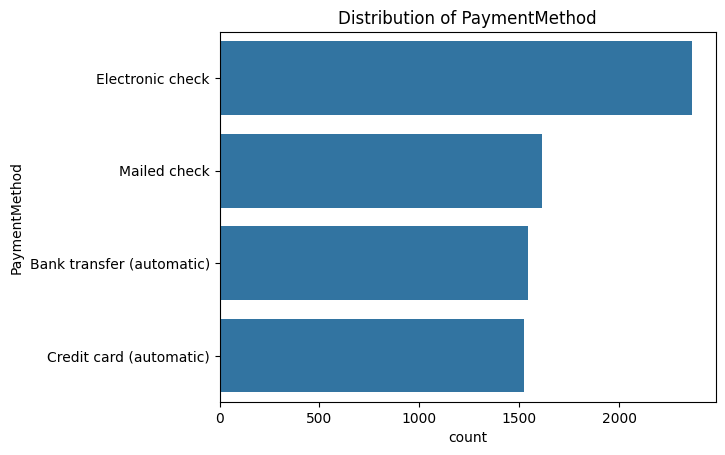

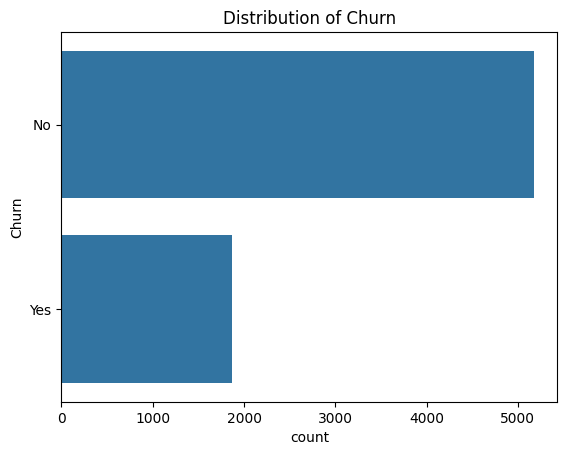

In [31]:
for col in cat_cols:
    plt.figure()
    sns.countplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

# **Bivariate Analysis**

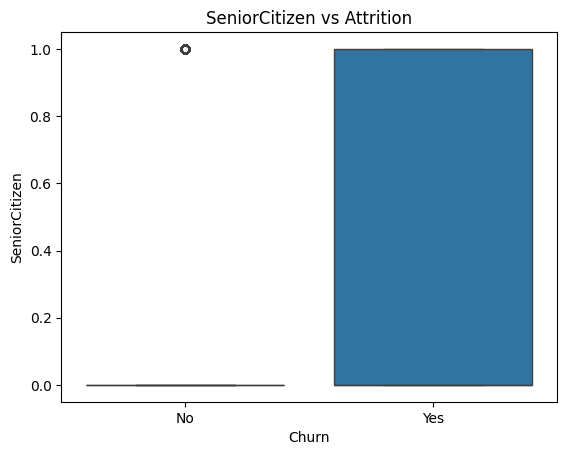

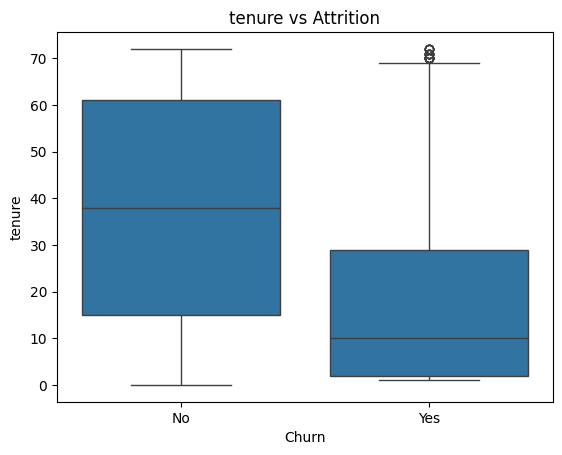

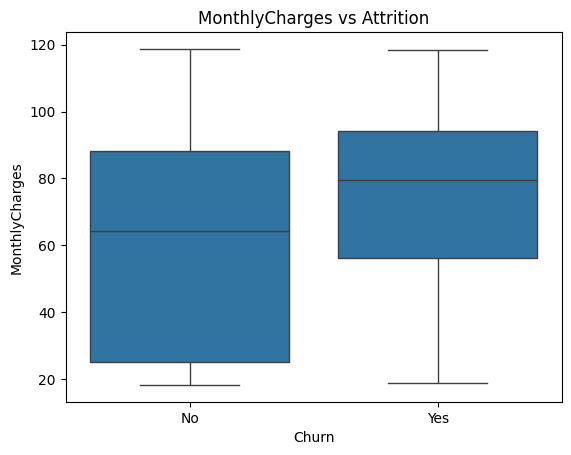

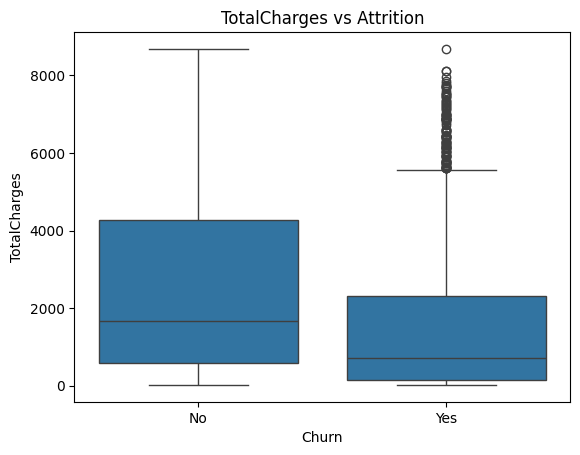

In [32]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Attrition')
    plt.show()

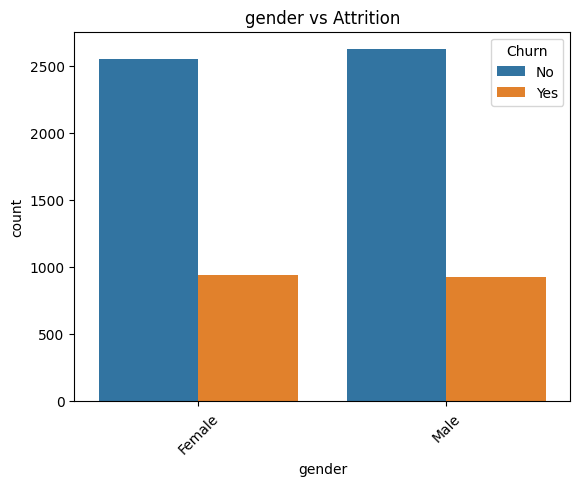

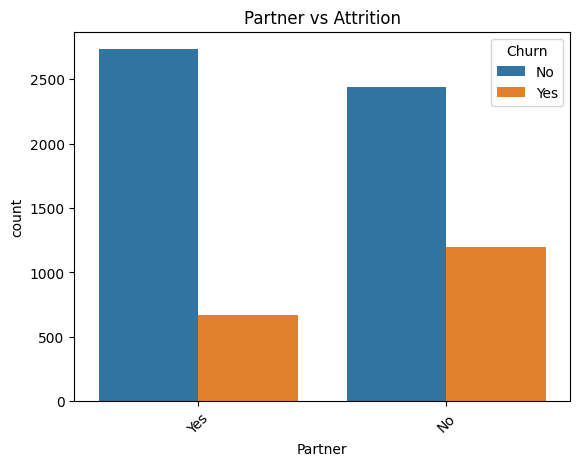

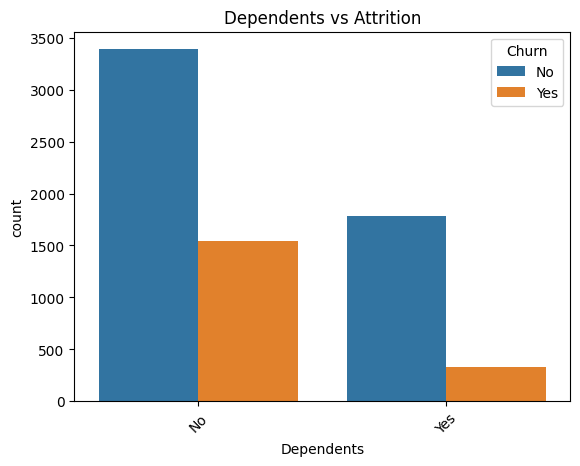

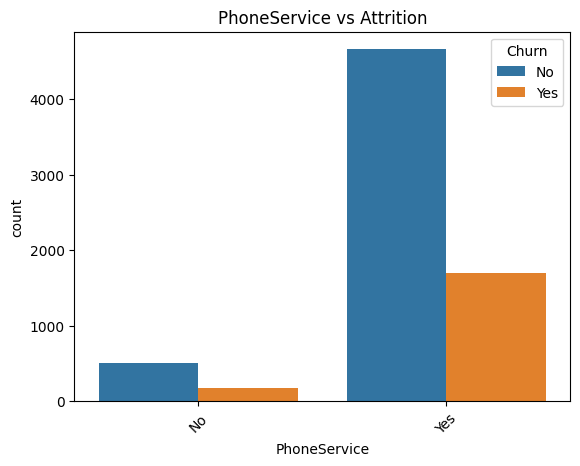

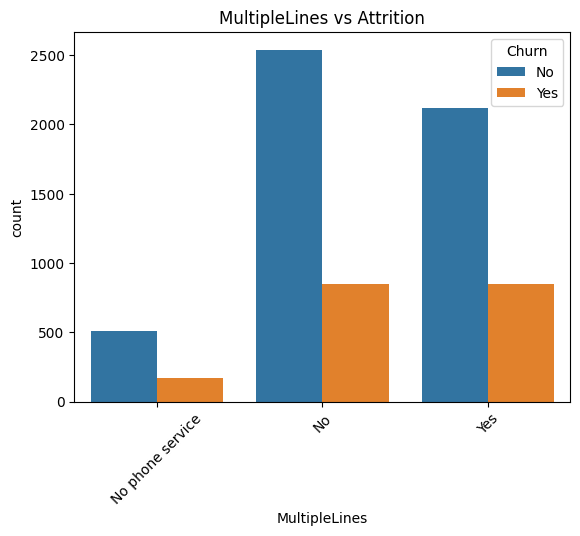

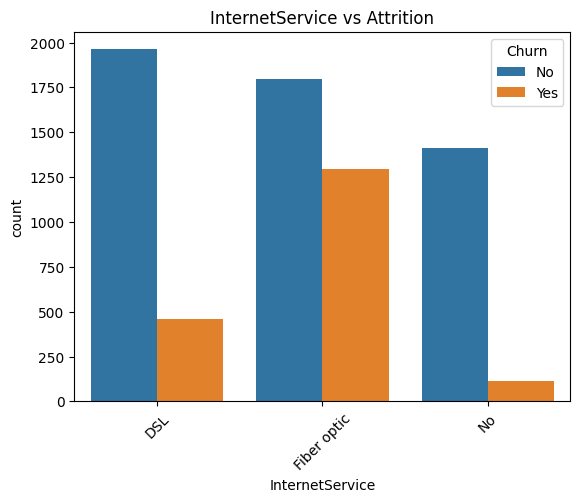

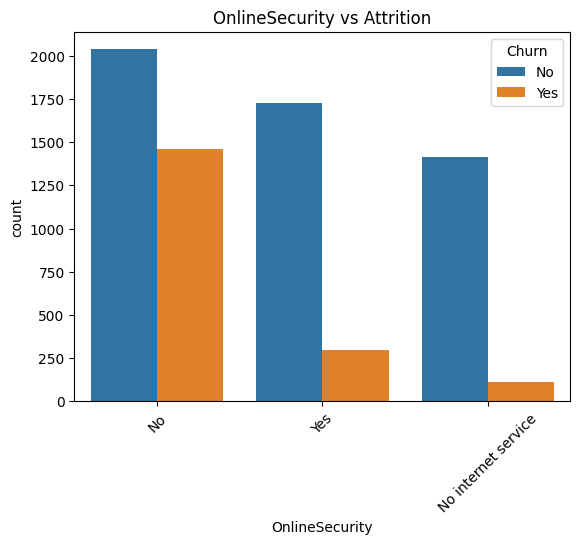

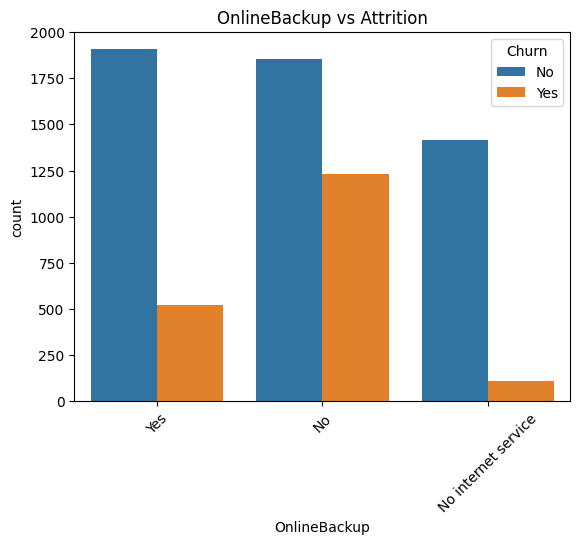

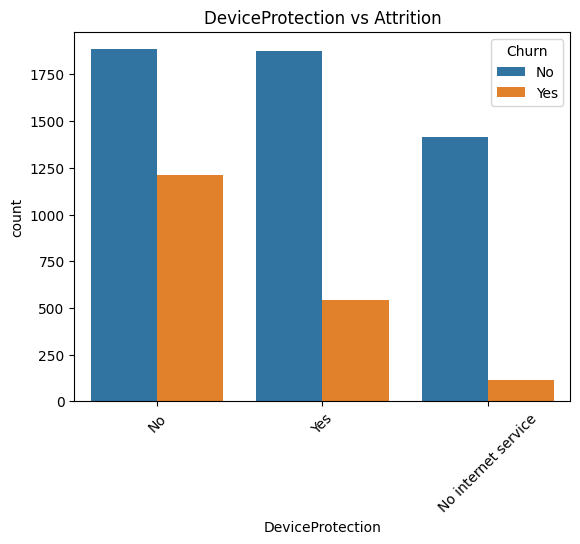

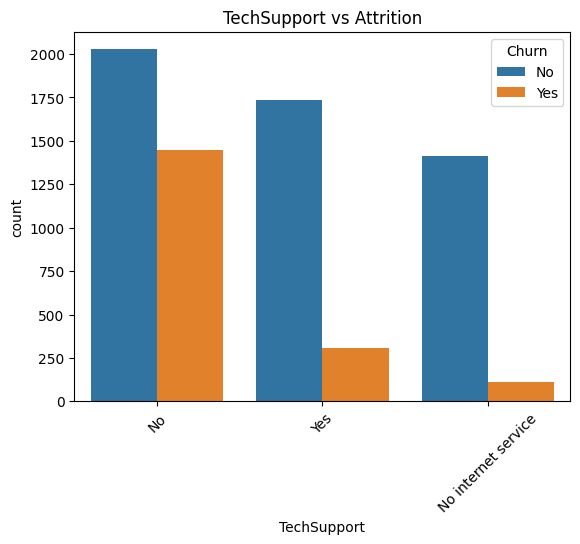

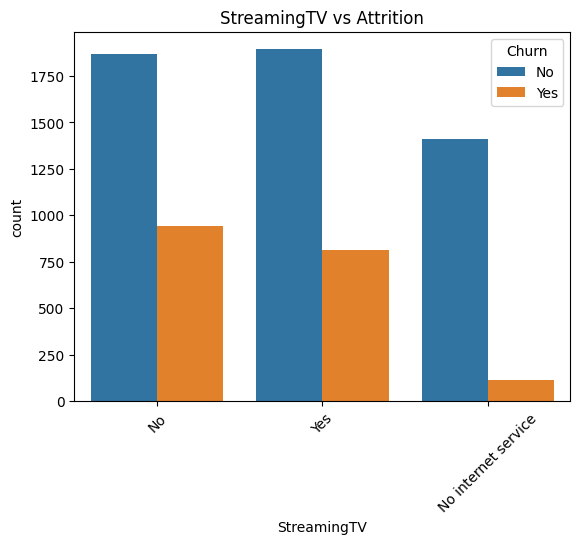

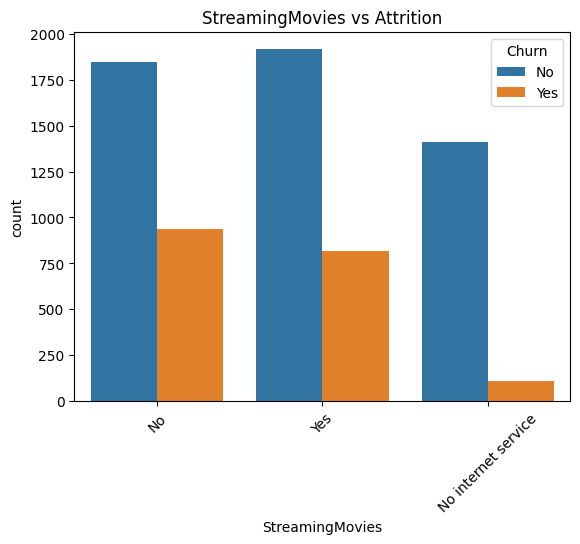

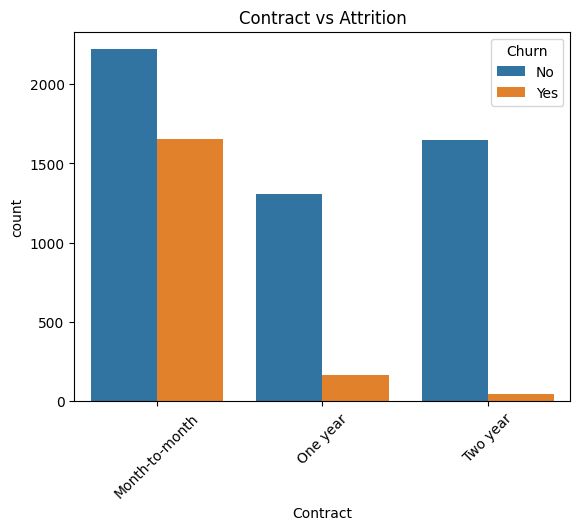

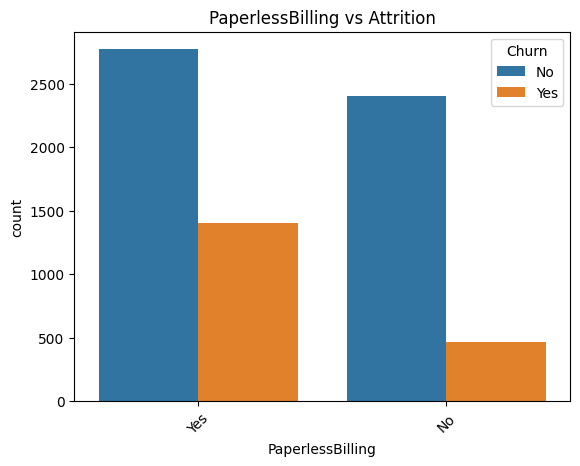

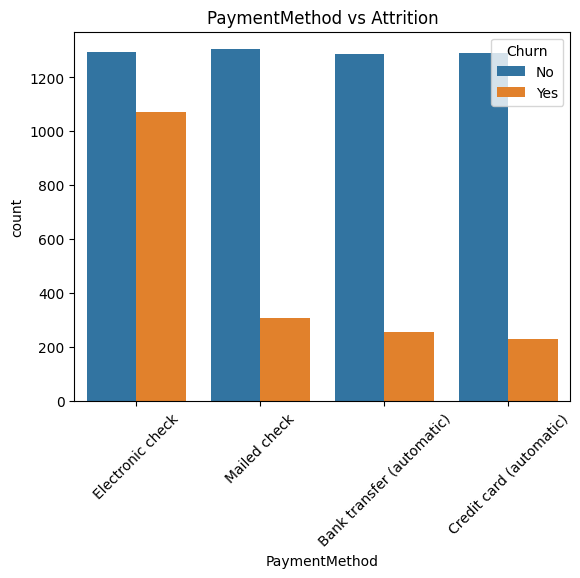

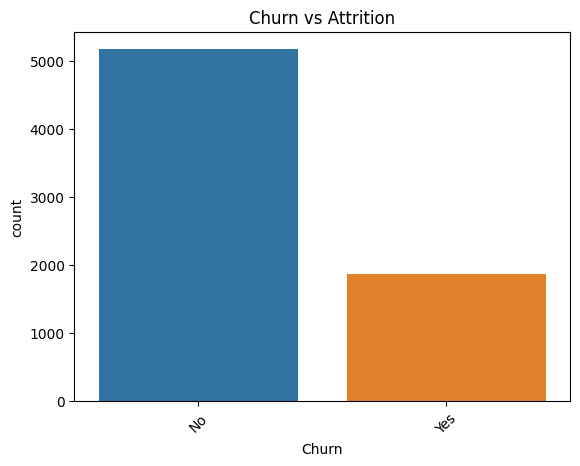

In [33]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col,hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Attrition')
    plt.show()

# **Correlation HeatMap**

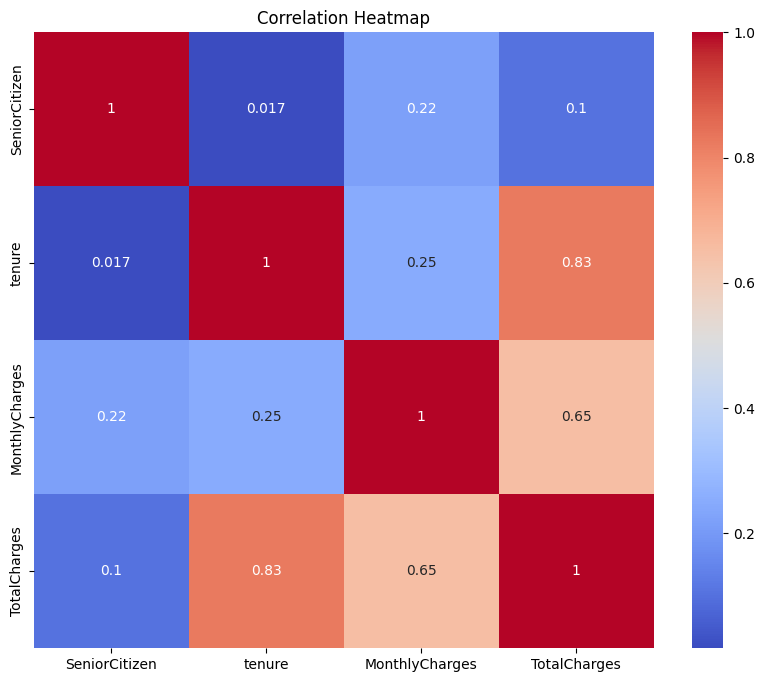

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **Detecting and Handling Outliers**

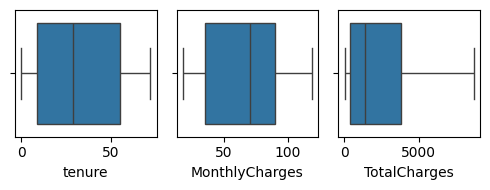

In [35]:
fig,ax=plt.subplots(1,3,figsize=(5,2))
sns.boxplot(df,x='tenure',ax=ax[0])
sns.boxplot(df,x='MonthlyCharges',ax=ax[1])
sns.boxplot(df,x='TotalCharges',ax=ax[2])
plt.tight_layout()

In [36]:
print(df['tenure'].skew())
print(df['MonthlyCharges'].skew())
print(df['TotalCharges'].skew())

0.2395397495619829
-0.22046922813679604
0.9647294463449093


In [37]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

In [38]:
df[df['TotalCharges']>upper]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [39]:
df[df['TotalCharges']<lower]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [40]:
df[(df['TotalCharges']>upper)|(df['TotalCharges']<lower)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [41]:
len(df[(df['TotalCharges']>upper)|(df['TotalCharges']<lower)])/len(df['TotalCharges']*100)

0.0

# **Label Encoder**

In [42]:
'''
female - 0
male - 1
'''

'\nfemale - 0\nmale - 1\n'

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [44]:
df = pd.get_dummies(df, drop_first=True)

In [45]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [46]:
df.shape

(7043, 31)

# **Train Test and Split**

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **Scaling**

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Handlng Imbalancies**

In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [50]:
# Ensure test is also DataFrame
X_test = pd.DataFrame(X_test, columns=X_train.columns)

In [51]:
X_train = X_train.values
X_test = X_test.values

# **Models**

# **Logistic Regression**

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
# Evaluate
print("=== Logistic Regression ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

=== Logistic Regression ===
Confusion Matrix
 [[815 220]
 [134 240]]
Accuracy: 0.7487579843860894
Recall: 0.6417112299465241
Precision: 0.5217391304347826
F1 Score: 0.5755395683453237


# **KNN**

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [57]:
# Evaluate
print("=== KNN ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

=== KNN ===
Confusion Matrix
 [[756 279]
 [142 232]]
Accuracy: 0.7012065294535131
Recall: 0.6203208556149733
Precision: 0.45401174168297453
F1 Score: 0.5242937853107345


# **Decision Tree**

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [59]:
# Evaluate
print("=== Decision Tree ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

=== Decision Tree ===
Confusion Matrix
 [[807 228]
 [169 205]]
Accuracy: 0.7182398864442867
Recall: 0.5481283422459893
Precision: 0.47344110854503463
F1 Score: 0.5080545229244114


with Hyperparameters

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,max_features='sqrt',
    splitter='best',min_samples_leaf=2,
    min_samples_split = 10 ,random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [61]:
# Evaluate
print("=== Decision Tree ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

=== Decision Tree ===
Confusion Matrix
 [[807 228]
 [119 255]]
Accuracy: 0.7537260468417317
Recall: 0.6818181818181818
Precision: 0.5279503105590062
F1 Score: 0.5950991831971996


# **Random Forest**

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [63]:
# Evaluate
print("=== Random Forest ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

=== Random Forest ===
Confusion Matrix
 [[863 172]
 [155 219]]
Accuracy: 0.7679205110007097
Recall: 0.5855614973262032
Precision: 0.5601023017902813
F1 Score: 0.5725490196078431


With hyperparameters

In [64]:
rf_model = RandomForestClassifier(
    n_estimators=200,max_depth=20,
    bootstrap=True,criterion='gini',
    max_features='sqrt',min_samples_split=10,
    min_samples_leaf=2,random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [65]:
# Evaluate
print("=== Random Forest ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

=== Random Forest ===
Confusion Matrix
 [[833 202]
 [132 242]]
Accuracy: 0.7629524485450674
Recall: 0.6470588235294118
Precision: 0.545045045045045
F1 Score: 0.5916870415647921


# **Support Vector Classifier**

In [66]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf',gamma=0.1,C=5)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)

In [67]:
# Evaluate
print("=== Support Vector ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_svc))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Recall:", recall_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))

=== Support Vector ===
Confusion Matrix
 [[921 114]
 [232 142]]
Accuracy: 0.7544357700496807
Recall: 0.37967914438502676
Precision: 0.5546875
F1 Score: 0.4507936507936508


# **Gradient Boosting Classifier**

In [68]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=10,max_depth=50,
                               learning_rate=0.01,
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
gb_model.fit(X_train,y_train)
y_pred_gb = gb_model.predict(X_test)

In [69]:
# Evaluate
print("=== Gradient Boosting ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

=== Gradient Boosting ===
Confusion Matrix
 [[846 189]
 [134 240]]
Accuracy: 0.7707594038325053
Recall: 0.6417112299465241
Precision: 0.5594405594405595
F1 Score: 0.597758405977584


# **XGBoost Classifier**

In [85]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=10,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha =0.1,
    reg_lambda = 0.5,
    n_jobs = -1
)
xgb_model.fit(X_train,y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [86]:
# Evaluate
print("=== XG Boost ===")
print("Confusion Matrix\n", confusion_matrix(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

=== XG Boost ===
Confusion Matrix
 [[820 215]
 [123 251]]
Accuracy: 0.7601135557132718
Recall: 0.6711229946524064
Precision: 0.5386266094420601
F1 Score: 0.5976190476190476


# **ROC - AUC**

In [88]:
log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
svc_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=-1, num_parallel_tree=None, ...)

In [89]:
from sklearn.metrics import roc_auc_score

auc_scores = {}

auc_scores["Logistic Regression"] = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])
auc_scores["Decision Tree"] = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])
auc_scores["Random Forest"] = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
auc_scores["KNN"] = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1])
auc_scores["Gradient Boosting"] = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])
auc_scores["XGBoost"] = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

# SVC case
auc_scores["SVC"] = roc_auc_score(y_test, svc_model.decision_function(X_test))

# Print nicely
for model, score in auc_scores.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8082
Decision Tree: 0.6628
Random Forest: 0.8175
KNN: 0.7403
Gradient Boosting: 0.8305
XGBoost: 0.8236
SVC: 0.6959


#**Hyper parameters**

**Logistic Regression**

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_model = LogisticRegression(max_iter=10000)

log_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

log_grid = GridSearchCV(log_model, log_params, cv=5, scoring='f1')
log_grid.fit(X_train, y_train)

print("Best Logistic:", log_grid.best_params_)

Best Logistic: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


**KNN**

In [74]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(knn_model, knn_params, cv=5, scoring='f1')
knn_grid.fit(X_train, y_train)

print("Best KNN:", knn_grid.best_params_)

Best KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


**Decision Tree**

In [75]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_params = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt_model, dt_params, cv=5, scoring='f1')
dt_grid.fit(X_train, y_train)

print("Best Decision Tree:", dt_grid.best_params_)

Best Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


**Random Forest Classifer**

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)

print("Best Random Forest:", rf_grid.best_params_)

Best Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


**SVC**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc_model = SVC(class_weight='balanced')

svc_params = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 5, 10, 20],
    'gamma': [0.1, 0.01, 0.001]
}


svc_grid = GridSearchCV(
    estimator=svc_model,
    param_grid=svc_params,
    cv=5,
    scoring='f1',
    n_jobs=1
)

svc_grid.fit(X_train, y_train)

print("Best SVC Parameters:", svc_grid.best_params_)

**Gradient Boosting**

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10]
}

gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='f1')
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting:", gb_grid.best_params_)

Best Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 100}


**XG Boost**

In [78]:
from xgboost import XGBClassifier

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

model = XGBClassifier(eval_metric='logloss')

parameters = {
    'max_depth': [3, 5, 10],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1, 2]
}

xgb_grid = GridSearchCV(model, parameters, cv=5, scoring='f1')
xgb_grid.fit(X_train, y_train)

print("Best XGBoost:", xgb_grid.best_params_)

Best XGBoost: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 1}


# **Model Performance**

In [103]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVC",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ],

    "AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, knn_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, svc_model.decision_function(X_test)),
        roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    ]
})

# Sort by best model
comparison = comparison.sort_values(by="F1 Score", ascending=False)

print(comparison)

                 Model  Accuracy    Recall  Precision  F1 Score       AUC
5    Gradient Boosting  0.770759  0.641711   0.559441  0.597758  0.830485
6              XGBoost  0.760114  0.671123   0.538627  0.597619  0.823591
1        Decision Tree  0.753726  0.681818   0.527950  0.595099  0.662846
2        Random Forest  0.762952  0.647059   0.545045  0.591687  0.817528
0  Logistic Regression  0.748758  0.641711   0.521739  0.575540  0.808236
3                  KNN  0.701207  0.620321   0.454012  0.524294  0.740303
4                  SVC  0.754436  0.379679   0.554688  0.450794  0.695885


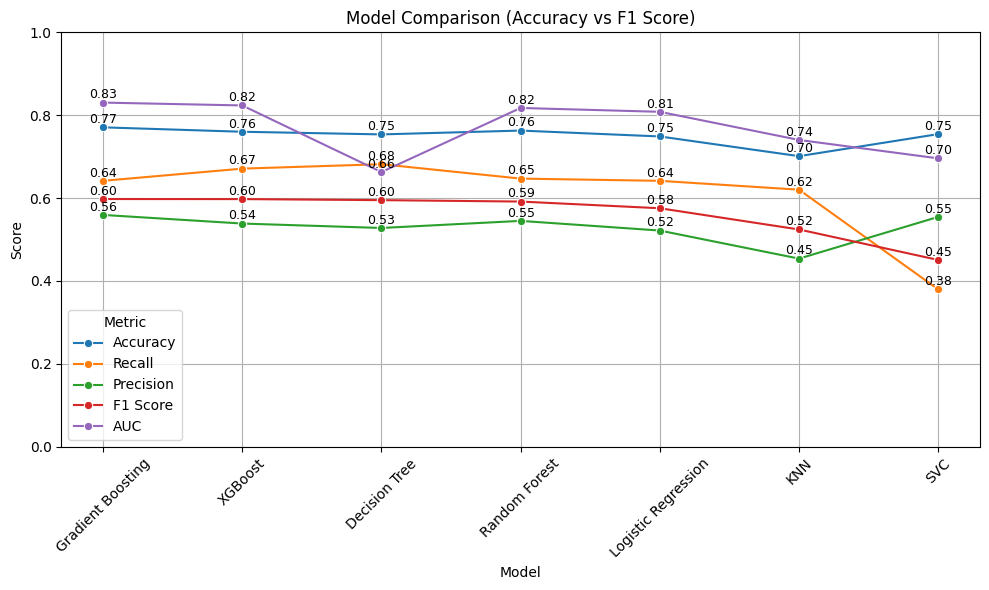

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter required columns
comparison_filtered = comparison[["Model", "Accuracy","Recall","Precision","F1 Score","AUC"]]

# Convert to long format
comparison_melted = comparison_filtered.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric",
    marker="o"
)

# Add value labels
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y + 0.01, f"{y:.2f}", ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.title("Model Comparison (Accuracy vs F1 Score)")
plt.ylim(0,1)
plt.grid()
plt.tight_layout()
plt.show()

# **Best Model**

In [99]:
best_model = comparison.iloc[0]
print("Best Model:\n", best_model)

Best Model:
 Model        Gradient Boosting
Accuracy              0.770759
Recall                0.641711
Precision             0.559441
F1 Score              0.597758
AUC                   0.830485
Name: 5, dtype: object


# **Conclusion**

## **🏆 Best Performing Model: Gradient Boosting**
- **F1 Score:** 0.5978 (Highest)
- **Accuracy:** 0.7708 (Highest)
- **AUC:** 0.8305 (Highest)

Gradient Boosting achieved the best overall performance, providing a strong balance between precision and recall. It is the most reliable model for this dataset.

## **🥈 Close Competitor: XGBoost**
- **F1 Score:** 0.5976
- **Accuracy:** 0.7601
- **AUC:** 0.8236

XGBoost performed almost as well as Gradient Boosting and is also a strong candidate due to its stability and efficiency.

## **🥉 Good Performing Models**

### Random Forest
- Balanced performance across all metrics  
- Strong AUC score (0.8175)

### Decision Tree
- Decent F1 Score  
- Lower AUC, indicating less stability compared to ensemble models  

## **⚖️ Moderate Model**

### Logistic Regression
- Provides stable baseline performance  
- Lower F1 Score compared to ensemble methods  

## ⚠️ **Weak Performing Models**

### KNN
- Lower F1 Score (0.5243)  
- Struggles with data distribution and generalization  

### SVC
- Lowest F1 Score (0.4508)  
- Very low recall → fails to identify many positive cases  


## 🔍 K**ey Observations**

### 1. Ensemble Models Perform Best
Gradient Boosting, XGBoost, and Random Forest outperform other models due to their ability to handle complex patterns.

### 2. Accuracy vs F1 Score
Accuracy values are similar (~0.75) across models, but F1 Score varies significantly.  
This indicates the presence of **class imbalance**, making F1 Score a more reliable metric.

### 3. Importance of Recall
Models like SVC show poor recall, meaning they fail to detect positive cases effectively.


## ✅ Final Conclusion

Gradient Boosting is the best-performing model, achieving the highest F1 Score, Accuracy, and AUC.  
Ensemble methods consistently outperform individual models, making them more suitable for this problem.

